In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn streamlit faker

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.0 MB 1.9 MB/s eta 0:00:01
   -------------------- ------------------- 1.0/2.0 MB 2.0 MB/s eta 0:00:01
   ------------------------------- -------- 1.6/2.0 MB 1.9 MB/s eta 0:00:01
   ------------------------------------ --- 1.8/2.0 MB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 1.9 MB/s eta 0:00:00


In [7]:
import pandas as pd
import numpy as np
from faker import Faker
import random
fake = Faker('en_IN')      
np.random.seed(42)         
random.seed(42)
n = 50000                   
fraud_ratio = 0.02      
merchants = ['Swiggy','Zomato','Amazon','Flipkart','BigBasket',
             'PhonePe','Paytm','Google Pay','IRCTC','BookMyShow',
             'Unknown_Merchant','Temp_Account','New_User_9999']
states = ['UP','Delhi','Maharashtra','Karnataka','Tamil Nadu',
          'Gujarat','Rajasthan','Bihar','West Bengal','Punjab']
data = []
for i in range(n):
    is_fraud = 1 if random.random() < fraud_ratio else 0
    hour = random.choice([2,3,4]) if is_fraud else random.randint(8,22)
    amount = round(random.uniform(50000,200000),2) if is_fraud else round(random.uniform(10,5000),2)
    merchant = random.choice(merchants[10:]) if is_fraud else random.choice(merchants[:10])
    new_device = 1 if is_fraud and random.random()<0.8 else 0
    failed_before = random.randint(3,10) if is_fraud else random.randint(0,1)
    diff_state = 1 if is_fraud and random.random()<0.7 else 0
    data.append({
        'transaction_id': f'TXN{100000+i}',
        'sender_upi': fake.bothify('????####@upi'),
        'receiver_upi': fake.bothify('????####@upi'),
        'amount': amount,
        'merchant': merchant,
        'hour_of_day': hour,
        'state': random.choice(states),
        'new_device': new_device,
        'failed_attempts_before': failed_before,
        'different_state': diff_state,
        'is_fraud': is_fraud    
    })
df = pd.DataFrame(data)
df.to_csv('upi_transactions.csv', index=False)
print(f"Dataset ready! Total: {n}, Fraud: {df['is_fraud'].sum()}")

Dataset ready! Total: 50000, Fraud: 1000


In [8]:
print(df.head())             
print("\nShape:", df.shape)  
print("\nFraud count:\n", df['is_fraud'].value_counts())

  transaction_id    sender_upi  receiver_upi   amount  merchant  hour_of_day  \
0      TXN100000  YGsm44977upi   nkvt3279upi  3710.34  Flipkart            8   
1      TXN100001  UqDj60194upi  Sieu53546upi  3705.93     IRCTC           18   
2      TXN100002   zhuJ3727upi   yTIG6839upi   477.54  Flipkart            8   
3      TXN100003  wtKp66457upi   BbHL5291upi  3509.61     Paytm           18   
4      TXN100004   rkak0712upi  QcRA94733upi  4347.81    Amazon           20   

         state  new_device  failed_attempts_before  different_state  is_fraud  
0  Maharashtra           0                       0                0         0  
1       Punjab           0                       0                0         0  
2  West Bengal           0                       0                0         0  
3        Bihar           0                       0                0         0  
4      Gujarat           0                       1                0         0  

Shape: (50000, 11)

Fraud count:
 is_f

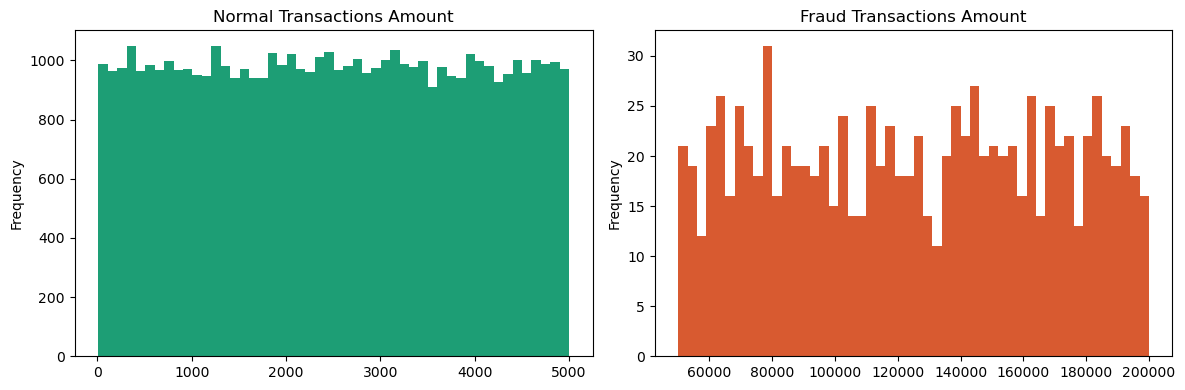

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df[df['is_fraud']==0]['amount'].clip(upper=10000).plot(
    kind='hist', bins=50, ax=axes[0],
    color='#1D9E75', title='Normal Transactions Amount')
df[df['is_fraud']==1]['amount'].plot(
    kind='hist', bins=50, ax=axes[1],
    color='#D85A30', title='Fraud Transactions Amount')
plt.tight_layout()
plt.show()

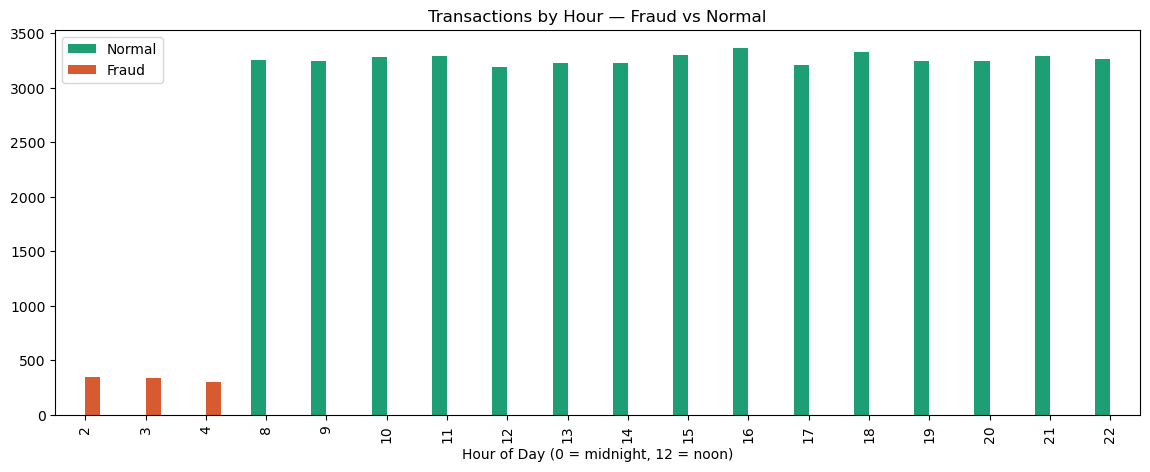

In [5]:
fraud_by_hour = df.groupby(['hour_of_day','is_fraud']).size().unstack()
fraud_by_hour.plot(kind='bar', figsize=(14,5), color=['#1D9E75','#D85A30'])
plt.title('Transactions by Hour — Fraud vs Normal')
plt.xlabel('Hour of Day (0 = midnight, 12 = noon)')
plt.legend(['Normal','Fraud'])
plt.show()

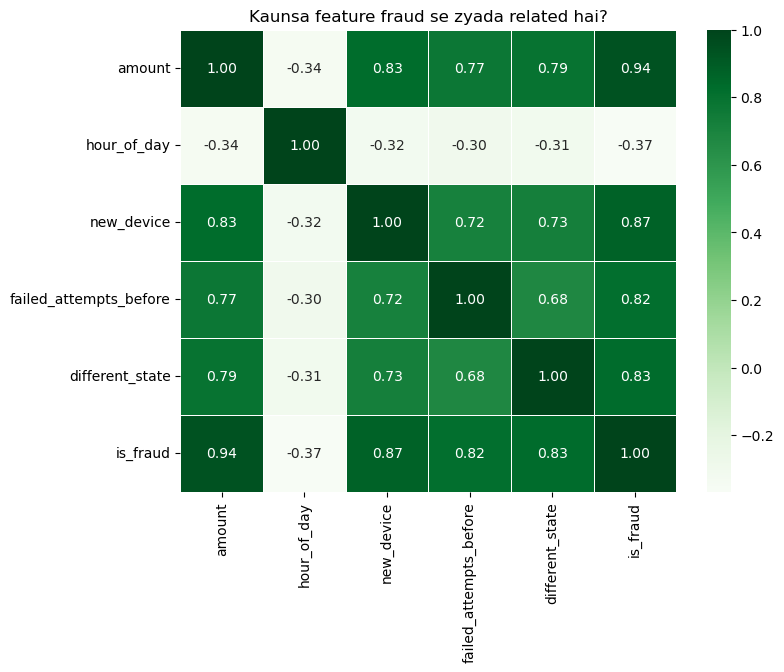

In [10]:
numeric_cols = ['amount','hour_of_day','new_device',
                'failed_attempts_before','different_state','is_fraud']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(),
            annot=True,     
            fmt='.2f',      
            cmap='Greens',
            linewidths=0.5)
plt.title('Kaunsa feature fraud se zyada related hai?')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
features = ['amount','hour_of_day','new_device',
            'failed_attempts_before','different_state']
X = df[features]           
y = df['is_fraud']     
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 5)
Testing data: (10000, 5)


In [12]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
print("SMOTE se pehle:")
print("  Normal:", (y_train==0).sum(), "| Fraud:", y_train.sum())
print("\nSMOTE ke baad:")
print("  Normal:", (y_res==0).sum(), "| Fraud:", y_res.sum())

SMOTE se pehle:
  Normal: 39206 | Fraud: 794

SMOTE ke baad:
  Normal: 39206 | Fraud: 39206


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_res, y_res)
y_pred = model.predict(X_test)
print("=== Model Results ===")
print(classification_report(y_test, y_pred,
      target_names=['Normal','Fraud']))

=== Model Results ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9794
       Fraud       1.00      1.00      1.00       206

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



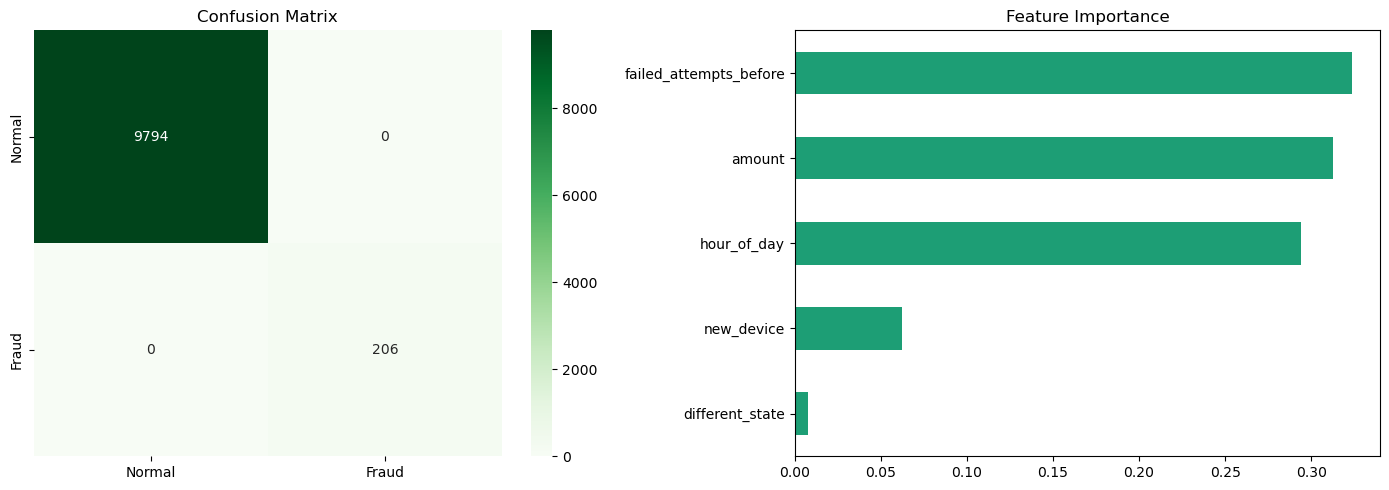

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
feat_imp = pd.Series(model.feature_importances_,
                     index=features).sort_values()
feat_imp.plot(kind='barh', color='#1D9E75', ax=axes[1])
axes[1].set_title('Feature Importance')
plt.tight_layout()
plt.show()